<!-- DEA Notebook Header -->
<div style="font-family:'Segoe UI',Roboto,sans-serif; line-height:1.6; color:CanvasText; padding:32px;">

<img src="https://raw.githubusercontent.com/GeoscienceAustralia/dea-notebooks/stable/Supplementary_data/dea_logo_wide.jpg" alt="DEA Notebooks logo" style="width:86.5%;">

<h1>Introduction to loading data with STAC</h1>

<p>
🔎 Visit <a href="https://knowledge.dea.ga.gov.au">DEA's Knowledge Hub</a> for detailed technical information about the datasets and concepts used in this notebook.
</p>

<p>
<span style="display:inline-block; font-size:12px; background:rgba(59,130,246,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🟢 Beginner</span>
<span style="display:inline-block; font-size:12px; background:rgba(16,185,129,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">⚡ Runtime: ~1 mins</span>
<span style="display:inline-block; font-size:12px; background:rgba(107,114,128,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🗓️ Updated: 2025-12</span>
</p>

<!-- Products - REQUIRED -->
<div style="margin-bottom:12px; padding:12px; background:rgba(59,130,246,0.08); border:1px solid rgb(59,130,246); border-radius:8px; max-width:85%;">
<b>📦 Products used</b><br>
<a href="https://knowledge.dea.ga.gov.au/data/product/dea-geometric-median-and-median-absolute-deviation-landsat/?tab=specifications">ga_ls8cls9c_gm_cyear_3</a>
</div>

<!-- Prerequisites - OPTIONAL, delete if not required -->
<div style="margin-bottom:12px; padding:12px; background:rgba(59,130,246,0.08); border:1px solid rgb(59,130,246); border-radius:8px; max-width:85%;">
<b>🧾 Prerequisites</b><br>
<a href="https://knowledge.dea.ga.gov.au/guides/setup/gis/stac/#Searching-for-STAC-data-using-pystac_clients">Consider reading this Knowledge Hub article on STAC</a>
</div>

<!-- How to run - REQUIRED -->
<div style="margin-bottom:12px; padding:12px; background:rgba(16,185,129,0.1); border:1px solid rgb(16,185,129); border-radius:8px; max-width:85%;">
<b>🚀 How you can run this notebook</b><br>

- <b>DEA Sandbox:</b> Eligible users can sign up for the <a href="https://sandbox.dea.ga.gov.au/">DEA Sandbox</a> that provides free compute and a managed Python environment.

- <b>Personal computer:</b> This notebook loads DEA data using <code>odc-stac</code>. Data streams via the internet, so can be run locally after installing the required <a href="https://pypi.org/project/dea-tools/">DEA Tools</a> Python package, e.g. <code>pip install dea-tools[notebooks]</code>.

- <b>Run this notebook online:</b> Click on the badge below to launch a GitHub Codespaces instance to run the notebook from your browser. See this <a href="">wiki page</a> for more information.

  <a href="https://codespaces.new/GeoscienceAustralia/dea-notebooks/tree/template?quickstart=1" target="_blank">
    <img src="https://img.shields.io/badge/Codespaces-Open-blue?logo=github" alt="Open in GitHub Codespaces" style="height:25px;">
  </a>
</div>

</div>


## Background
Loading data from the [Digital Earth Australia (DEA)](https://www.ga.gov.au/dea) instance of the [Open Data Cube](https://www.opendatacube.org/) requires the construction of a query that specifies the what, where, and when of the data request.
Each query returns a [multi-dimensional xarray object](http://xarray.pydata.org/en/stable/) containing the contents of your query.

It is essential to understand the `xarray` data structures as they are fundamental to the structure of data loaded from the datacube.

Manipulations, transformations and visualisation of `xarray` objects provide datacube users with the ability to explore and analyse DEA datasets, as well as pose and answer scientific questions.

## Description

This tutorial demonstrates how to use the [odc-stac](https://odc-stac.readthedocs.io/en/latest/) Python package to load data from DEA using the [DEA Explorer STAC API](https://explorer.dea.ga.gov.au/products). The `odc-stac` package translates STAC metadata to the Open Data Cube data model, allowing you to load DEA data into `xarray.Dataset` format to be processed locally.

This notebook will introduce how to load data from the DEA through the construction of a query and use of the `odc.stac.load()` function.

Topics covered include:

1. Loading data using `odc.stac.load()`
2. Interpreting the resulting `xarray.Dataset` object
3. Customising parameters passed to the `odc.stac.load()` function
    * Projecting data to a new CRS and spatial resolution 
    * Specifying a specific spatial resampling method
4. Loading matching data from multiple products using `like`

***

## Load packages
Import Python packages that are used for the analysis.

Use standard import commands; some are shown below.
Begin with any `iPython` magic commands (if required), followed by standard Python packages, then any additional functionality from the `dea_tools` Python package.

In [1]:
%matplotlib inline

import odc.stac
import pystac_client
from odc.geo import BoundingBox
from odc.geo.xr import assign_crs

import matplotlib.pyplot as plt
from dea_tools.plotting import rgb

## Connect to DEA's STAC API

This allows us to search for data using DEA's STAC API (refer to the [SpatioTemporal Asset Catalogue guide](https://knowledge.dea.ga.gov.au/guides/setup/gis/stac/) for details).

To load data, we must also configure access to DEA's Amazon S3 buckets using `odc.stac.configure_s3_access`.
If launching a Dask client (e.g. `dea_tools.dask.create_local_dask_cluster()`), this is done automatically.

In [2]:
# Configure data access
odc.stac.configure_s3_access(cloud_defaults=True, aws_unsigned=True)

# Connect to STAC API
catalog = pystac_client.Client.open("https://explorer.dea.ga.gov.au/stac")

## Analysis Parameters

First we need to define the location, time period and DEA product we want to load.

In this example, we will load a Landsat 8-9 geomedian from 2017 over Canberra.

In [3]:
# Set a bounding box based on a point location and a buffer region
central_lat, central_lon = -35.3, 149.125
buffer = 0.05

# Set a loading date - Landsat geomedians are annual products
start_date = "2017-01-01"
end_date = "2017-12-31"

# Set product ID as the STAC "collection"
collections = ["ga_ls8cls9c_gm_cyear_3"]

### Create and plot the bounding box region-of-interest

In [4]:
# Compute the bounding box object for the study area
bbox = BoundingBox(
    left=central_lon - buffer,
    bottom=central_lat - buffer,
    right=central_lon + buffer,
    top=central_lat + buffer,
    crs="EPSG:4326"
)

bbox.explore()

## Searching for STAC data using `pystac_client`

We can use the `pystac_client` Python package to search for STAC items that match our query:

In [5]:
# Build a query with the parameters above
query = catalog.search(
    bbox=bbox,
    collections=collections,
    datetime=f"{start_date}/{end_date}",
)

# Search the STAC catalog for all items matching the query
items = list(query.items())
print(f"Found: {len(items):d} datasets")

Found: 2 datasets


## Loading data using `odc.stac.load()`

Loading data through DEA's STAC API uses the [odc.stac.load()](https://odc-stac.readthedocs.io/en/latest/_api/odc.stac.load.html) function.

The function requires the following minimum arguments:

* `items`: a list of STAC items, we found these in the cell above based on our query. 
* `bands`: List of band names to load, for example `['nbart_red']`. By default, this function will load all the bands available in the product.

Additionally, there are many other parameters we can pass to control the dimensions of the pixel grid, resampling and reprojection methods, additional filtering based on metadata etc. Some of these we will explore further below.  

In this first example, lets also pass:
* `resolution`: spatial resolution of output in units of the output CRS.
* `crs`: Load data in a given CRS.

Run the following cell to load the red, green, and blue bands from the `ga_ls8cls9c_gm_cyear_3` product.

In [6]:
ds = odc.stac.load(
    items,
    bands=["nbart_red", "nbart_green", "nbart_blue"],
    crs="EPSG:3577", # geomedians are stored Albers Equal Area
    resolution=30, # spatial resolution in metres
    bbox=bbox
)

### Plot

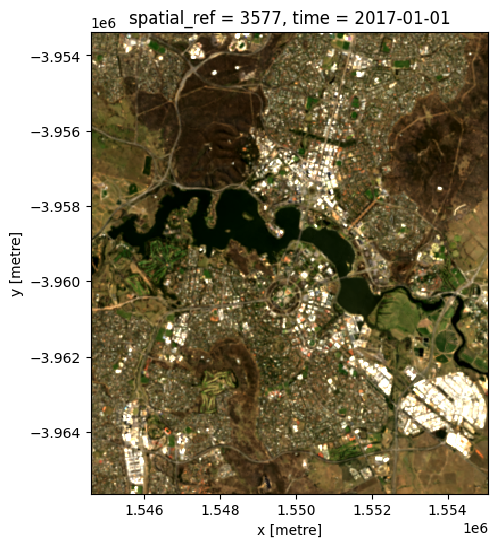

In [7]:
rgb(ds);

### Interpreting the resulting `xarray.Dataset`
The variable `ds` (printed in the cell below) has returned an `xarray.Dataset` containing all data that matched the spatial and temporal query parameters inputted into `odc.stac.load`.

*Dimensions* 

* This header identifies the number of timesteps returned in the search (`time: 1`) as well as the number of pixels in the `x` and `y` directions of the data query.

*Coordinates* 

* `time` identifies the date attributed to each returned timestep.
* `x` and `y` are the coordinates for each pixel within the spatial bounds of the query.
* The attributes of the `spatial_ref` coordinate contains the coordinate reference system (CRS) information of the loaded data (try running `print(ds.spatial_ref)` in a new cell) . Alternatively, you can also run `ds.odc.geobox` to see similar information.

*Data variables*

* These are the measurements available for the nominated product. 
For every date (`time`) returned by the query, the measured value at each pixel (`y`, `x`) is returned as an array for each measurement.
Each data variable is itself an `xarray.DataArray` object ([see below](#Inspecting-an-individual-xarray.DataArray)). 



In [8]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:      (y: 409, x: 350, time: 1)
Coordinates:
  * y            (y) float64 3kB -3.953e+06 -3.953e+06 ... -3.966e+06 -3.966e+06
  * x            (x) float64 3kB 1.545e+06 1.545e+06 ... 1.555e+06 1.555e+06
  * time         (time) datetime64[ns] 8B 2017-01-01
    spatial_ref  int32 4B 3577
Data variables:
    nbart_red    (time, y, x) float32 573kB 837.0 852.0 917.0 ... 887.0 880.0
    nbart_green  (time, y, x) float32 573kB 781.0 784.0 813.0 ... 759.0 761.0
    nbart_blue   (time, y, x) float32 573kB 562.0 563.0 612.0 ... 515.0 509.0

## Customising the `odc.stac.load()` function

The `odc.stac.load()` function can be tailored to refine a query.

Two important customisations options include:

* `group_by:` Satellite datasets based around scenes can have multiple observations per day with slightly different time stamps as the satellite collects data along its path.
These observations can be combined by reducing the `time` dimension to the day level using `group_by=solar_day`.
* `resampling`: This argument allows you to specify a custom spatial resampling method to use when data is reprojected into a different CRS. 

Example syntax for the resampling methods are outlined below

### CRS Reprojection

Certain applications may require that data is output into a specific CRS.
Data can be reprojected by specifying the new `crs` and identifying the `resolution` required.

The example cell below reprojects data to a new CRS (UTM Zone 55S, `EPSG:32355`) and resolution (90 x 90 m). 

We also specify _how_ to resample. The `resampling` parameter allows you to choose a custom resampling method from the following options.

```
"nearest", "cubic", "bilinear", "cubic_spline", "lanczos", 
"average", "mode", "gauss", "max", "min", "med", "q1", "q3"
```

Python dictionaries can be used to request **different sampling methods for different bands**. 
This can be particularly useful when some measurements contain contain categorical data which require resampling methods such as "nearest" or "mode" that do not modify the input pixel values.

For example, to resample the `fmask` variable (contained with scene based Landsat products) with 'nearest', and every other band with 'average', the syntax would be this: `resampling={"oa_fmask": "nearest", "nbart_red": "average"}`, 

In [9]:
ds_reprojected = odc.stac.load(
    items,
    bands=["nbart_red", "nbart_green", "nbart_blue"],
    crs="EPSG:32355", # UTM zone for canberra
    resolution=120, # spatial resolution in metres
    resampling='average', #resample all bands with average statistic
    bbox=bbox
)

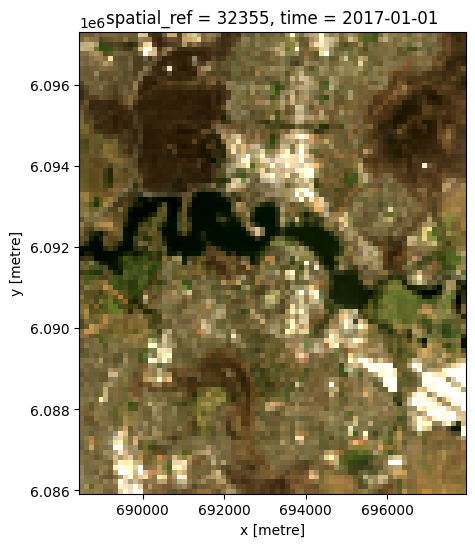

In [10]:
rgb(ds_reprojected, size=6)

### Loading data "like" another dataset

Another option for loading matching data from multiple products is to use `odc.stac.load()`'s `like` parameter.

This will copy the spatial extent and the CRS/resolution from an existing dataset, and use these parameters to load new data from a new product.

The example cell below loads a Landsat 7 geomedian dataset that exactly matches the `ds` dataset loaded earlier:


In [11]:
# Build a query with the parameters above
query = catalog.search(
    bbox=bbox,
    collections=['ga_ls7e_gm_cyear_3'],
    datetime=f"{start_date}/{end_date}",
)

# Search the STAC catalog for all items matching the query
items = list(query.items())

# load data with same pixel grid and extents as out repvious example
ds_ls7 = odc.stac.load(
    items,
    bands=["nbart_red", "nbart_green", "nbart_blue"],
    like=ds #
)

ds_ls7

<xarray.Dataset> Size: 2MB
Dimensions:      (y: 409, x: 350, time: 1)
Coordinates:
  * y            (y) float64 3kB -3.953e+06 -3.953e+06 ... -3.966e+06 -3.966e+06
  * x            (x) float64 3kB 1.545e+06 1.545e+06 ... 1.555e+06 1.555e+06
  * time         (time) datetime64[ns] 8B 2017-01-01
    spatial_ref  int32 4B 3577
Data variables:
    nbart_red    (time, y, x) float32 573kB 871.0 885.0 923.0 ... 838.0 832.0
    nbart_green  (time, y, x) float32 573kB 778.0 780.0 788.0 ... 693.0 696.0
    nbart_blue   (time, y, x) float32 573kB 519.0 518.0 547.0 ... 385.0 369.0

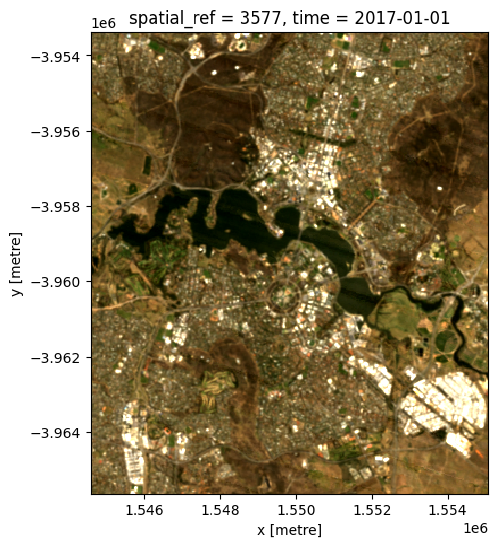

In [12]:
rgb(ds_ls7)

## Recommended next steps

To continue working through the notebooks in this beginner's guide, the following notebooks are designed to be worked through in the following order:

1. [Jupyter Notebooks](01_Jupyter_notebooks.ipynb)
2. [Digital Earth Australia](02_DEA.ipynb)
3. [Products and measurements](03_Products_and_measurements.ipynb)
4. **Loading data (this notebook)**
5. [Plotting](05_Plotting.ipynb)
6. [Performing a basic analysis](06_Basic_analysis.ipynb)
7. [Introduction to Numpy](07_Intro_to_numpy.ipynb)
8. [Introduction to Xarray](08_Intro_to_xarray.ipynb)
9. [Parallel processing with Dask](09_Parallel_processing_with_Dask.ipynb)

Once you have worked through the beginner's guide, you can join advanced users by exploring:

* A demonstration of how to load cloud-free observations in the [using load_ard](../How_to_guides/Using_load_ard.ipynb) notebook.
* The "DEA products" directory in the repository, where you can explore DEA products in depth.
* The "How_to_guides" directory, which contains a recipe book of common techniques and methods for analysing DEA data.
* The "Real_world_examples" directory, which provides more complex workflows and analysis case studies.

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last tested:**


In [13]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2025-12-01'